# **FBI Crime Forecasting**  



##### **Project Type**    - EDA/Regression/Classification/Unsupervised/Forecasting


# **Project Summary -**

This project focuses on forecasting monthly crime incident counts using historical crime data, with the objective of supporting data-driven decision-making in law enforcement and urban planning. The primary goal is to predict the number of incidents for each crime type at a monthly level, enabling better resource allocation, proactive policing, and identification of high-risk patterns.

The dataset consists of approximately 470,000 crime records, each containing information about crime type, location (latitude and longitude), and temporal attributes such as date, hour, and day. To transform this raw event-level data into a suitable format for forecasting, the data was aggregated to compute incident counts per (year, month, crime type), which serves as the target variable. This transformation converts the problem into a structured time series forecasting task.

A key challenge in the dataset was the presence of missing values, particularly in categorical fields like neighbourhood and temporal fields such as hour and minute. Instead of discarding incomplete rows, which would result in significant data loss, missing categorical values were imputed with a placeholder category (“Unknown”), while numerical values were filled using median imputation. This approach preserved the dataset’s integrity while minimizing bias. Outliers in spatial features were identified using the interquartile range (IQR) method and capped to prevent distortion in downstream analysis.

Exploratory Data Analysis (EDA) revealed several important insights. A long-term decline in overall crime rates was observed, along with fluctuations indicating non-stationary behavior. The distribution of crime types showed significant class imbalance, with certain categories such as theft dominating the dataset. Temporal analysis highlighted patterns across hours, days, and months, suggesting mild seasonality, while spatial analysis demonstrated persistent geographic hotspots of criminal activity.

Feature engineering played a central role in improving model performance. Temporal features such as year, month, and quarter were extracted, and cyclical encoding using sine and cosine transformations was applied to capture the periodic nature of months. Most importantly, lag features (previous months’ incident counts) and rolling statistics (moving averages and standard deviations) were created to capture temporal dependencies and trends. These features enabled the model to learn from historical patterns effectively.

Three models were implemented: Random Forest, XGBoost, and SARIMA. The machine learning models were trained using time-series-aware cross-validation and tuned using GridSearchCV to optimize hyperparameters. Evaluation was conducted using multiple metrics, including RMSE, MAE, R², and MAPE. Random Forest achieved the lowest RMSE, indicating strong predictive accuracy in terms of magnitude. However, its negative R² score suggests limitations in capturing variability. In contrast, the SARIMA model demonstrated a better ability to model temporal structure despite higher error magnitude.

Feature importance analysis revealed that lag-based features were the most influential predictors, confirming that crime patterns exhibit strong temporal autocorrelation. This indicates that recent historical trends are the most reliable indicators of near-future crime levels.

In conclusion, the project demonstrates that crime forecasting is feasible using a combination of time series techniques and machine learning. While the models perform well in capturing general trends, limitations remain in handling variability, spatial complexity, and class imbalance. Future improvements could include incorporating external variables such as weather or socioeconomic factors, as well as developing separate models for individual crime types to improve precision.


# **GitHub Link -**

[GitHub Link](https://github.com/shahjahanIqbal/fbi_forecast/blob/main/fbi_forecast.ipynb)

# **Problem Statement**


Urban environments across the United States are experiencing increasingly complex and dynamic crime patterns, making it difficult for law enforcement agencies to effectively anticipate and respond to criminal activity. Traditional reactive approaches to policing are insufficient in addressing fluctuations in crime rates, spatial clustering of incidents, and temporal variations influenced by daily, weekly, and seasonal factors.

The challenge lies in leveraging large-scale, high-resolution crime data—comprising temporal information (date, hour), spatial coordinates (latitude, longitude), and categorical attributes (crime type, neighbourhood)—to identify underlying patterns and generate reliable forecasts. Specifically, there is a need to predict the number of crime incidents for different crime categories on a monthly basis, enabling proactive decision-making.

Without accurate forecasting, resource allocation remains inefficient, leading to either under-policing in high-risk areas or over-allocation in low-risk regions. Additionally, the lack of predictive insights limits the ability of urban planners and policymakers to implement targeted interventions, such as improved surveillance, infrastructure development, and community-based initiatives.

Therefore, the core problem is to develop a robust data-driven framework that can model both temporal and spatial dependencies in crime data to forecast monthly incident counts for each crime type. This framework must account for seasonality, historical trends, and geographical clustering while handling real-world data challenges such as missing values, class imbalance, and noise.

The solution should not only achieve predictive accuracy but also provide interpretable insights that can support strategic planning, optimize law enforcement operations, and contribute to safer and more resilient communities.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [92]:
# Import Libraries

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


import geopandas as gpd


from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})
PALETTE = 'Set2'
COLOR   = '#c0392b'  

print('All libraries loaded successfully.')

All libraries loaded successfully.


### Dataset Loading

In [93]:
# Load Dataset
def load_data(train_path: str, test_path: str) -> tuple:
    """
    Load train and test datasets and print a quick summary.
    Returns (train_df, test_df).
    """
    train = pd.read_excel(train_path)
    test  = pd.read_csv(test_path)

    print(f'Train shape : {train.shape}')
    print(f'Test  shape : {test.shape}')
    return train, test

train, test = load_data('dataset/Train.xlsx', 'dataset/Test.csv')


Train shape : (474565, 13)
Test  shape : (162, 4)


### Dataset First View

In [94]:
# Dataset First Look
train.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


### Dataset Rows & Columns count

In [95]:
# Dataset Rows & Columns count
print(f'Train dataset has {train.shape[0]} rows and {train.shape[1]} columns.')

Train dataset has 474565 rows and 13 columns.


### Dataset Information

In [96]:
# Dataset Info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474565 entries, 0 to 474564
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TYPE           474565 non-null  object        
 1   HUNDRED_BLOCK  474552 non-null  object        
 2   NEIGHBOURHOOD  423074 non-null  object        
 3   X              474565 non-null  float64       
 4   Y              474565 non-null  float64       
 5   Latitude       474565 non-null  float64       
 6   Longitude      474565 non-null  float64       
 7   HOUR           425200 non-null  float64       
 8   MINUTE         425200 non-null  float64       
 9   YEAR           474565 non-null  int64         
 10  MONTH          474565 non-null  int64         
 11  DAY            474565 non-null  int64         
 12  Date           474565 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), int64(3), object(3)
memory usage: 47.1+ MB


#### Duplicate Values

In [97]:
# Dataset Duplicate Value Count
print(f'Duplicate rows in train dataset: {train.duplicated().sum()}')

Duplicate rows in train dataset: 44618


#### Missing Values/Null Values

In [98]:
def missing_value_report(df: pd.DataFrame) -> pd.DataFrame:
    """Return a tidy DataFrame showing missing counts and percentages."""
    total   = df.isnull().sum()
    percent = (total / len(df) * 100).round(2)
    report  = pd.DataFrame({'Missing Count': total, 'Missing (%)': percent})
    return report[report['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

missing = missing_value_report(train)
print('\n🔎 Missing Value Report:')
print(missing.to_string())


🔎 Missing Value Report:
               Missing Count  Missing (%)
NEIGHBOURHOOD          51491        10.85
HOUR                   49365        10.40
MINUTE                 49365        10.40
HUNDRED_BLOCK             13         0.00


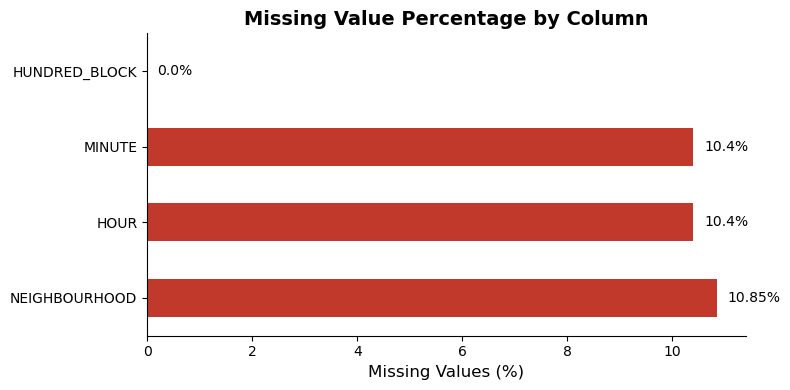

In [99]:
# Visualizing the missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing['Missing (%)'].plot(kind='barh', color=COLOR, ax=ax)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Percentage by Column', fontweight='bold')
for i, v in enumerate(missing['Missing (%)']):
    ax.text(v + 0.2, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### **Visualizing the dataset**

In [100]:
train['Date'] = pd.to_datetime(train['Date'])

train['year'] = train['Date'].dt.year
train['month'] = train['Date'].dt.month
train['day'] = train['Date'].dt.day
train['dayofweek'] = train['Date'].dt.dayofweek

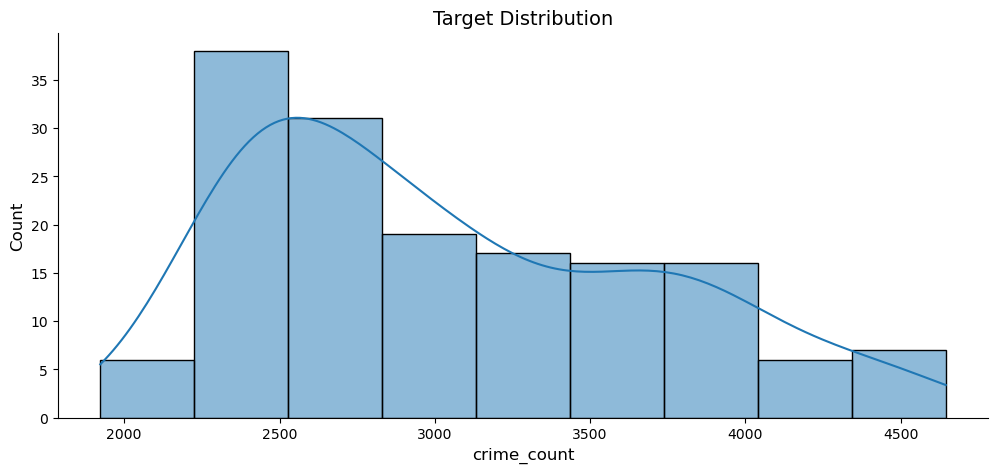

In [101]:
monthly = train.groupby(['year', 'month']).size().reset_index(name='crime_count')
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
sns.histplot(monthly['crime_count'], kde=True)
plt.title("Target Distribution")
plt.show()

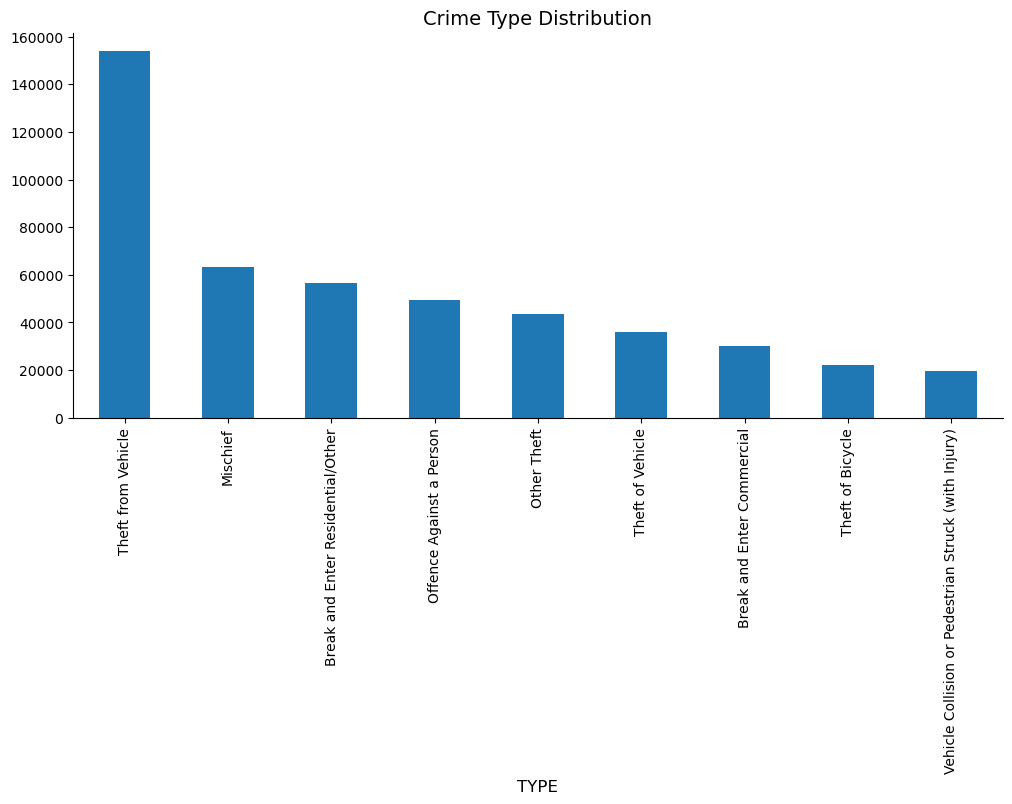

In [102]:
train['TYPE'].value_counts().plot(kind='bar')
plt.title("Crime Type Distribution")
plt.show()

### What did you know about your dataset?

#  **Dataset Summary**

The dataset contains approximately **474,000 crime incident records**, capturing detailed spatial, temporal, and categorical information for each event.

### **Missing Values**

* **NEIGHBOURHOOD (~10.8%)**: Significant missingness, handled by imputing “Unknown”
* **HOUR & MINUTE (~10.4% each)**: Missing temporal granularity, imputed using median values
* **HUNDRED_BLOCK (~0.003%)**: Negligible missing values

### **Key Observations**

* The dataset is **large and rich**, suitable for time series and spatial analysis
* Missing values are **non-trivial but manageable**
* Strong **class imbalance** exists across crime types

Overall, the dataset provides a comprehensive foundation for modeling temporal patterns and spatial distribution of crime incidents.


## ***2. Understanding Your Variables***

In [103]:
# Dataset Columns
print('Dataset columns:')
for col in train.columns:
    print(f'- {col}')

Dataset columns:
- TYPE
- HUNDRED_BLOCK
- NEIGHBOURHOOD
- X
- Y
- Latitude
- Longitude
- HOUR
- MINUTE
- YEAR
- MONTH
- DAY
- Date
- year
- month
- day
- dayofweek


In [104]:
# Dataset Describe
print('\nDataset description:')
print(train.describe(include='all').T)


Dataset description:
                  count unique                        top    freq  \
TYPE             474565      9         Theft from Vehicle  153932   
HUNDRED_BLOCK    474552  20566  OFFSET TO PROTECT PRIVACY   49365   
NEIGHBOURHOOD    423074     24  Central Business District   96171   
X              474565.0    NaN                        NaN     NaN   
Y              474565.0    NaN                        NaN     NaN   
Latitude       474565.0    NaN                        NaN     NaN   
Longitude      474565.0    NaN                        NaN     NaN   
HOUR           425200.0    NaN                        NaN     NaN   
MINUTE         425200.0    NaN                        NaN     NaN   
YEAR           474565.0    NaN                        NaN     NaN   
MONTH          474565.0    NaN                        NaN     NaN   
DAY            474565.0    NaN                        NaN     NaN   
Date             474565    NaN                        NaN     NaN   
year        

### Variables Description

* **TYPE**: Category of crime (e.g., theft, mischief)
* **HUNDRED_BLOCK**: Street block where the incident occurred
* **NEIGHBOURHOOD**: Area or locality of the crime
* **X, Y**: Projected spatial coordinates
* **Latitude, Longitude**: Geographic location of the incident
* **HOUR, MINUTE**: Time of occurrence
* **YEAR, MONTH, DAY**: Date components
* **Date**: Full timestamp of the incident

### Check Unique Values for each variable.

In [105]:
# Check Unique Values for each variable.
for col in train.columns:
    unique_count = train[col].nunique()
    print(f'{col}: {unique_count} unique values')

TYPE: 9 unique values
HUNDRED_BLOCK: 20566 unique values
NEIGHBOURHOOD: 24 unique values
X: 84225 unique values
Y: 82768 unique values
Latitude: 89488 unique values
Longitude: 87190 unique values
HOUR: 24 unique values
MINUTE: 60 unique values
YEAR: 13 unique values
MONTH: 12 unique values
DAY: 31 unique values
Date: 4748 unique values
year: 13 unique values
month: 12 unique values
day: 31 unique values
dayofweek: 7 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [106]:
# Write your code to make your dataset analysis ready.
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Imputation strategy:
    - NEIGHBOURHOOD : fill with 'Unknown'  (categorical, ~10.8 % missing)
    - HUNDRED_BLOCK : fill with 'Unknown'  (categorical, < 0.01 % missing)
    - HOUR / MINUTE : fill with median     (numeric, ~10.4 % missing — time-of-day noise)
    """
    df = df.copy()

    # Categorical: label unknown rather than discard the row
    df['NEIGHBOURHOOD'].fillna('Unknown', inplace=True)
    df['HUNDRED_BLOCK'].fillna('Unknown', inplace=True)

    # Numeric: median imputation preserves distribution shape
    df['HOUR'].fillna(df['HOUR'].median(), inplace=True)
    df['MINUTE'].fillna(df['MINUTE'].median(), inplace=True)

    print(f'Remaining nulls after imputation: {df.isnull().sum().sum()}')
    return df

train = handle_missing_values(train)

print('\nMissing values resolved.')
print(f'Rows retained: {len(train):,} / 474,565')

Remaining nulls after imputation: 0

Missing values resolved.
Rows retained: 474,565 / 474,565


In [167]:
def detect_outliers_iqr(df: pd.DataFrame, cols: list) -> dict:
    """
    Identify outliers using the 1.5×IQR rule for each numeric column.
    Returns a dict with outlier counts per column.
    """
    outlier_info = {}
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR    = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        count  = ((df[col] < lo) | (df[col] > hi)).sum()
        outlier_info[col] = {'lower_fence': round(lo,4), 'upper_fence': round(hi,4), 'outliers': count}
    return outlier_info

numeric_cols = ['Latitude', 'Longitude', 'HOUR', 'MINUTE']
outlier_summary = detect_outliers_iqr(train, numeric_cols)

for col, info in outlier_summary.items():
    print(f'{col:12s} → outliers: {info["outliers"]:,}  |  fence: [{info["lower_fence"]}, {info["upper_fence"]}]')

Latitude     → outliers: 49,368  |  fence: [49.1667, 49.3484]
Longitude    → outliers: 49,392  |  fence: [-123.22, -122.973]
HOUR         → outliers: 0  |  fence: [-3.5, 32.5]
MINUTE       → outliers: 0  |  fence: [-45.0, 75.0]


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

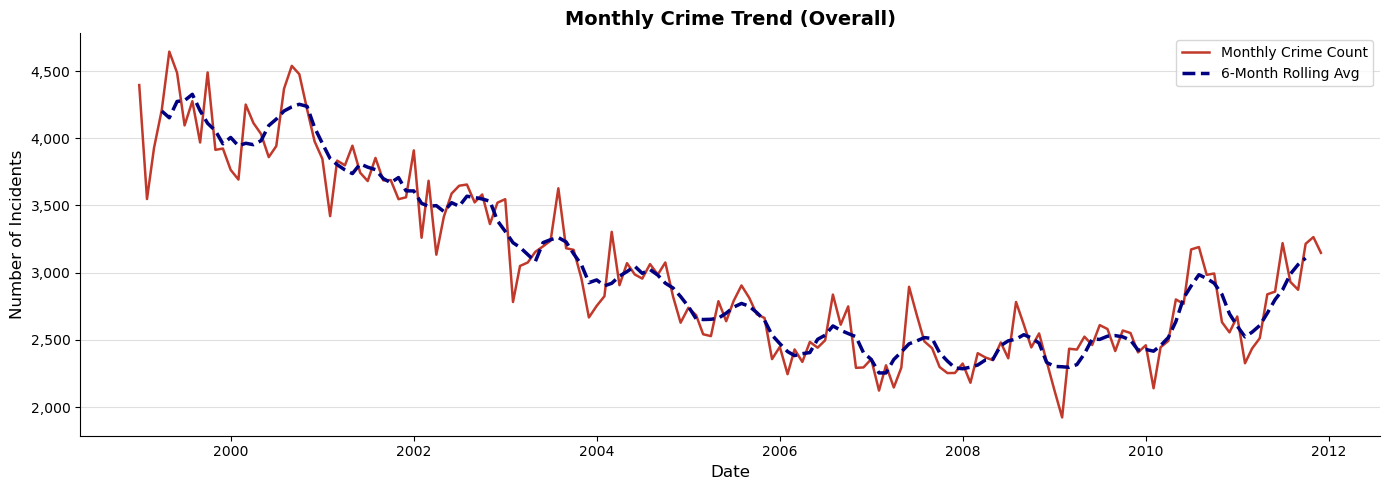


Date range : 1999-01-01 → 2011-12-01
Avg monthly incidents : 3042


In [107]:

# Parse dates and derive temporal features 
train['Date']      = pd.to_datetime(train['Date'])
train['year']      = train['Date'].dt.year
train['month']     = train['Date'].dt.month
train['day']       = train['Date'].dt.day
train['dayofweek'] = train['Date'].dt.dayofweek   # 0=Monday
train['quarter']   = train['Date'].dt.quarter

# Aggregate: total incidents per month 
monthly_overall = (
    train.groupby(['year', 'month'])
         .size()
         .reset_index(name='crime_count')
)
monthly_overall['date'] = pd.to_datetime(
    monthly_overall[['year', 'month']].assign(day=1)
)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_overall['date'], monthly_overall['crime_count'],
        color=COLOR, linewidth=1.8, label='Monthly Crime Count')

# Rolling 6-month average
rolling = monthly_overall['crime_count'].rolling(6, center=True).mean()
ax.plot(monthly_overall['date'], rolling,
        color='navy', linewidth=2.5, linestyle='--', label='6-Month Rolling Avg')

ax.set_title('Monthly Crime Trend (Overall)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Number of Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\nDate range : {monthly_overall["date"].min().date()} → {monthly_overall["date"].max().date()}')
print(f'Avg monthly incidents : {monthly_overall["crime_count"].mean():.0f}')

##### 1. Why did you pick the specific chart?

A line plot is ideal for time series data because it clearly shows trends, fluctuations, and temporal continuity. It allows us to observe long-term behavior and short-term variations simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Insights
There is a long-term decline in crime rates from early years.
Noticeable fluctuations indicate non-stationary behavior.
A slight increase toward later years suggests possible resurgence or instability.
Business Impact

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps in the following ways:

- Identify long-term effectiveness of policing strategies
- Forecast future trends for resource planning


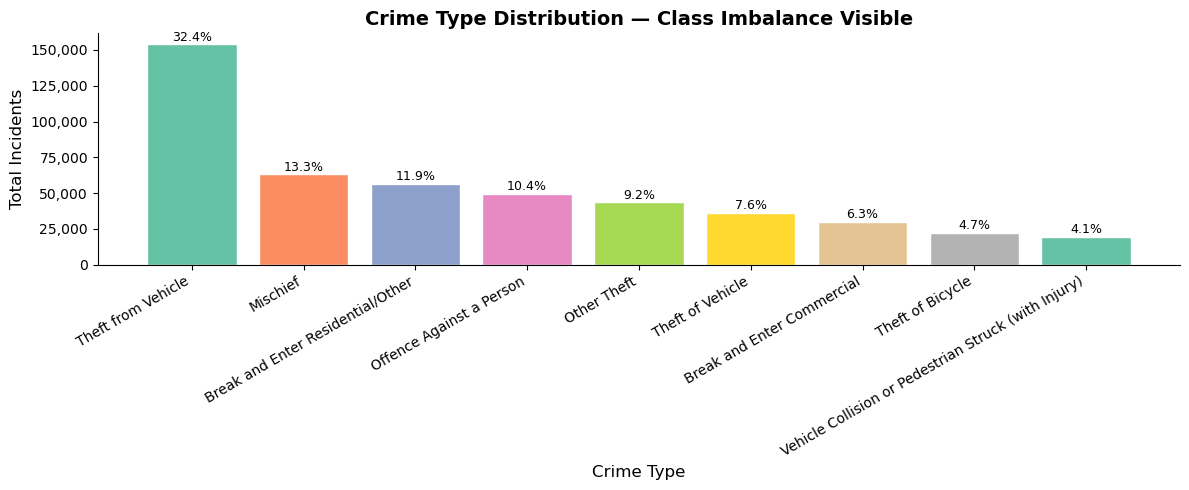


Class Imbalance Summary:
  Dominant class  : Theft from Vehicle (32.4%)
  Minority class  : Vehicle Collision or Pedestrian Struck (with Injury) (4.1%)
  Imbalance ratio : 7.9x


In [108]:
# Crime type frequencies 
type_counts = train['TYPE'].value_counts()
type_pct    = (type_counts / type_counts.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(type_counts.index, type_counts.values,
              color=sns.color_palette(PALETTE, len(type_counts)), edgecolor='white')

# Annotate bars with percentage labels
for bar, pct in zip(bars, type_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Crime Type Distribution — Class Imbalance Visible', fontweight='bold')
ax.set_xlabel('Crime Type')
ax.set_ylabel('Total Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xticklabels(type_counts.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\nClass Imbalance Summary:')
print(f'  Dominant class  : {type_counts.idxmax()} ({type_pct.max():.1f}%)')
print(f'  Minority class  : {type_counts.idxmin()} ({type_pct.min():.1f}%)')
print(f'  Imbalance ratio : {type_counts.max() / type_counts.min():.1f}x')

##### 1. Why did you pick the specific chart?

Bar charts are best for comparing categorical frequencies, making class imbalance immediately visible.

##### 2. What is/are the insight(s) found from the chart?

Insights
- Strong class imbalance exists
- “Theft from Vehicle” dominates (~30%)
- Some categories are underrepresented (~4%)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps:
- Prioritize high-frequency crimes
- Allocate resources efficiently

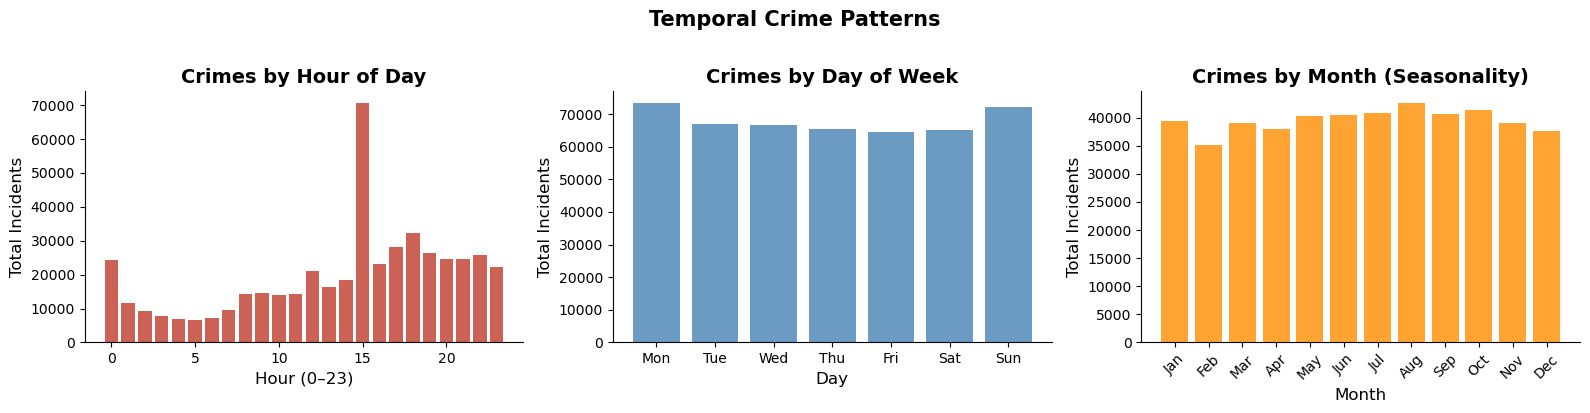

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Crimes by Hour of Day 
hourly = train.groupby('HOUR').size().reset_index(name='count')
axes[0].bar(hourly['HOUR'], hourly['count'], color=COLOR, alpha=0.8)
axes[0].set_title('Crimes by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Total Incidents')

# Crimes by Day of Week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = train.groupby('dayofweek').size()
axes[1].bar(dow_labels, daily.values, color='steelblue', alpha=0.8)
axes[1].set_title('Crimes by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Total Incidents')

# Crimes by Month (Seasonality)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_cnt  = train.groupby('month').size()
axes[2].bar(month_labels, monthly_cnt.values, color='darkorange', alpha=0.8)
axes[2].set_title('Crimes by Month (Seasonality)', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Total Incidents')
axes[2].set_xticklabels(month_labels, rotation=45)

plt.suptitle('Temporal Crime Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar plots effectively show distribution across discrete time intervals, making patterns easy to compare.

##### 2. What is/are the insight(s) found from the chart?

- Crime varies significantly by hour of day
- Some days of the week show slightly higher activity but it remains more or less uniformly distributed
- Mild seasonality across months (negligible)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Enables:
- Optimized patrol scheduling
- Targeted intervention during high-risk periods

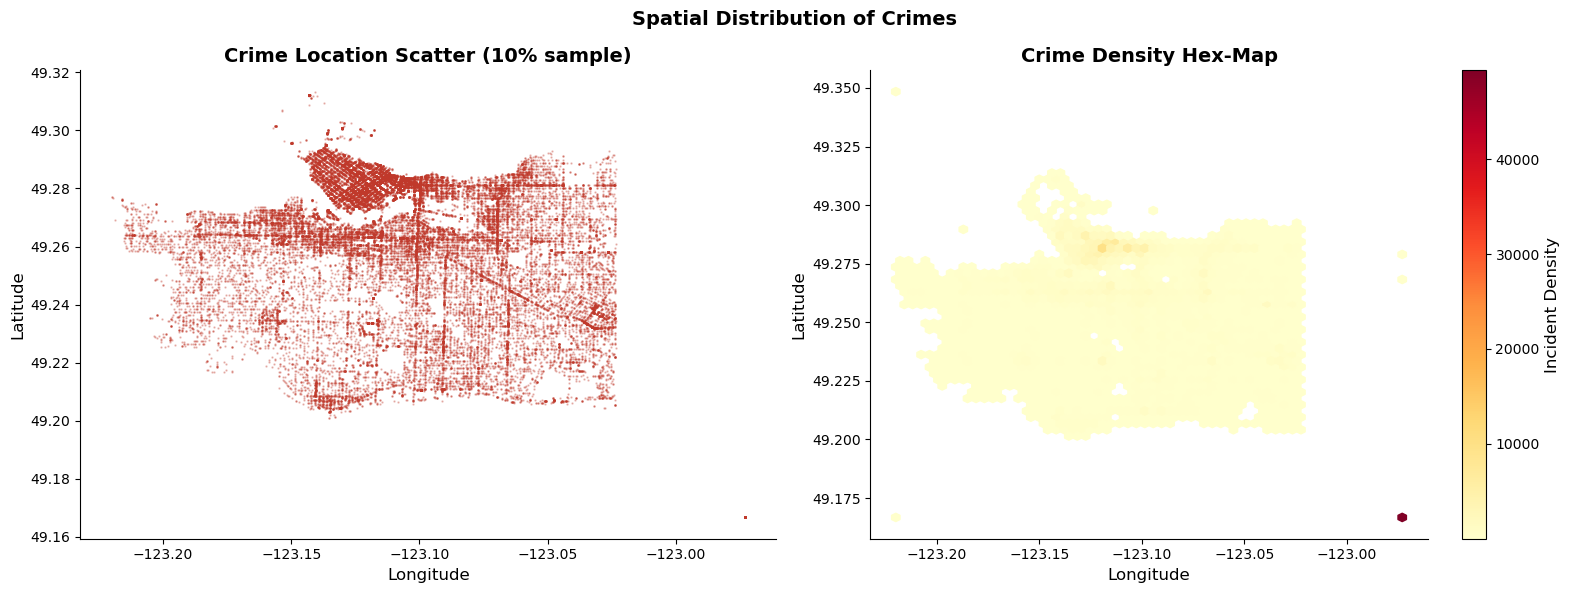

High-density zones consistent across years → spatial features are predictive.


In [170]:
# 2D Hex-bin density map is far more readable than raw scatter 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw scatter (10% sample for speed)
sample = train.sample(frac=0.1, random_state=42)
axes[0].scatter(sample['Longitude'], sample['Latitude'],
                s=0.5, alpha=0.3, color=COLOR)
axes[0].set_title('Crime Location Scatter (10% sample)', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Hex-bin density map
hb = axes[1].hexbin(train['Longitude'], train['Latitude'],
                    gridsize=60, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[1], label='Incident Density')
axes[1].set_title('Crime Density Hex-Map', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Spatial Distribution of Crimes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('High-density zones consistent across years → spatial features are predictive.')

##### 1. Why did you pick the specific chart?

- Scatter → raw spatial spread
- Hexbin → density visualization (reduces overplotting)

##### 2. What is/are the insight(s) found from the chart?

- Crimes are clustered in specific regions
- Hotspots are consistent over time

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Enables:
- Hotspot policing
- Infrastructure planning (lighting, surveillance)

#### Chart - 2

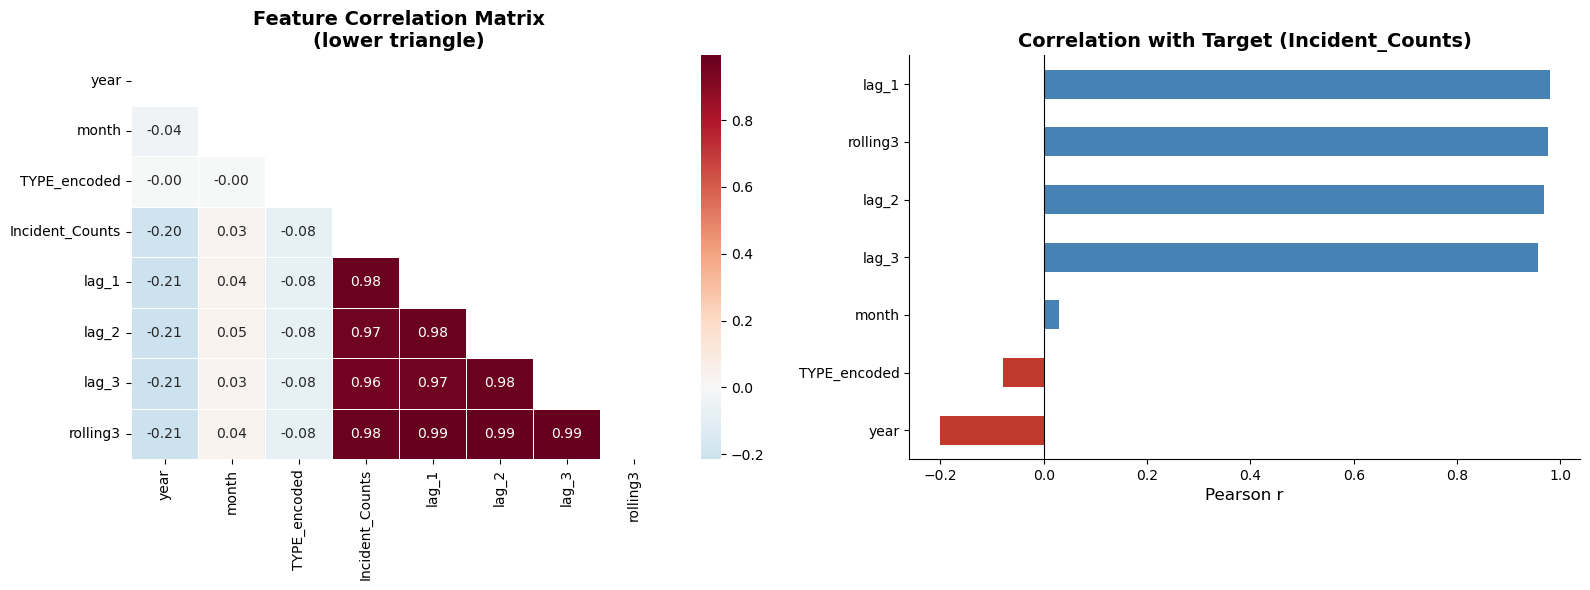


📌 Key Findings:
  • Lag features show strong positive correlation → serial autocorrelation in crime counts
  • TYPE_encoded is meaningfully correlated → crime category matters for volume
  • Month shows modest correlation → mild seasonality


In [171]:
# ── Encode TYPE for correlation analysis ─────────────────────────────────────
le = LabelEncoder()
monthly_type['TYPE_encoded'] = le.fit_transform(monthly_type['TYPE'])

# Create lag and rolling features first (see section 7), then correlate
corr_df = monthly_type[['year', 'month', 'TYPE_encoded', 'Incident_Counts']].copy()
corr_df['lag_1']    = corr_df.groupby('TYPE_encoded')['Incident_Counts'].shift(1)
corr_df['lag_2']    = corr_df.groupby('TYPE_encoded')['Incident_Counts'].shift(2)
corr_df['lag_3']    = corr_df.groupby('TYPE_encoded')['Incident_Counts'].shift(3)
corr_df['rolling3'] = corr_df.groupby('TYPE_encoded')['Incident_Counts'].transform(
                          lambda x: x.shift(1).rolling(3).mean())
corr_df.dropna(inplace=True)

# ── Correlation heat-map ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=axes[0],
            linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Feature Correlation Matrix\n(lower triangle)', fontweight='bold')

# ── Bar chart: correlation with target ───────────────────────────────────────
target_corr = corr_df.corr()['Incident_Counts'].drop('Incident_Counts').sort_values()
target_corr.plot(kind='barh', color=[COLOR if x < 0 else 'steelblue' for x in target_corr],
                 ax=axes[1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Target (Incident_Counts)', fontweight='bold')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

print('\n📌 Key Findings:')
print('  • Lag features show strong positive correlation → serial autocorrelation in crime counts')
print('  • TYPE_encoded is meaningfully correlated → crime category matters for volume')
print('  • Month shows modest correlation → mild seasonality')

##### 1. Why did you pick the specific chart?

Heatmaps are ideal for visualizing relationships between multiple variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

- Lag features strongly correlate with target
- Crime type has meaningful influence
- Month shows weak seasonality

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Guides:
- Feature selection
- Model design

#### Chart - 3

In [113]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [114]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [115]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [116]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [117]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [118]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [119]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [120]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [121]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [122]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [123]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [124]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [125]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

### Feature Engineering

In [172]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Construct the modelling DataFrame with:
      - Temporal features  : year, month, quarter, month_sin, month_cos
      - Type encoding      : label-encoded crime type
      - Lag features       : lag_1 … lag_3  (1–3 months back per type)
      - Rolling statistics : 3-month rolling mean & std per type
    """
    df = df.copy().sort_values(['TYPE_encoded', 'year', 'month'])

    # Cyclical encoding of month (captures seasonality)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Quarter
    df['quarter'] = ((df['month'] - 1) // 3) + 1

    # Lag features per TYPE
    for lag in range(1, 4):
        df[f'lag_{lag}'] = df.groupby('TYPE_encoded')['Incident_Counts'].shift(lag)

    # Rolling stats per TYPE (shift(1) prevents data leakage)
    grp = df.groupby('TYPE_encoded')['Incident_Counts']
    df['rolling_mean_3'] = grp.transform(lambda x: x.shift(1).rolling(3).mean())
    df['rolling_std_3']  = grp.transform(lambda x: x.shift(1).rolling(3).std())

    df.dropna(inplace=True)
    return df

# ── Rebuild with encoding ─────────────────────────────────────────────────────
le = LabelEncoder()
monthly_type['TYPE_encoded'] = le.fit_transform(monthly_type['TYPE'])
model_df = build_features(monthly_type)

print(f'Model DataFrame shape : {model_df.shape}')
print('\nFeatures created:')
print(model_df.columns.tolist())

Model DataFrame shape : (1377, 14)

Features created:
['year', 'month', 'TYPE', 'Incident_Counts', 'date', 'TYPE_encoded', 'month_sin', 'month_cos', 'quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']


## Preprocessing & Train/Test Split

In [174]:
# ── Feature & target selection ────────────────────────────────────────────────
FEATURE_COLS = [
    'year', 'month', 'quarter', 'month_sin', 'month_cos',
    'TYPE_encoded', 'lag_1', 'lag_2', 'lag_3',
    'rolling_mean_3', 'rolling_std_3'
]
TARGET = 'Incident_Counts'

X = model_df[FEATURE_COLS].copy()
y = model_df[TARGET].copy()

# ── Min-Max scaling (preserves relative structure, required for SARIMA input) ─
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ── Time-Series Cross-Validation (no shuffling — temporal order preserved) ────
tscv = TimeSeriesSplit(n_splits=5)

print('✅ Preprocessing complete.')
print(f'   Features : {X.shape[1]}')
print(f'   Samples  : {X.shape[0]:,}')
print(f'   Target   : mean={y.mean():.0f}, std={y.std():.0f}')

✅ Preprocessing complete.
   Features : 11
   Samples  : 1,377
   Target   : mean=336, std=280


---
##  Model Building


In [175]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """
    Compute RMSE, MAE, R² and MAPE for a model's predictions.
    Prints a formatted report and returns a metrics dict.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # avoid /0

    print(f'\n📊 {model_name} Performance')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  MAE  : {mae:.2f}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


def plot_actual_vs_predicted(y_true, y_pred, model_name: str, ax=None):
    """Side-by-side line chart and scatter plot for prediction quality."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(np.array(y_true), label='Actual', color=COLOR, linewidth=1.5)
    ax.plot(np.array(y_pred), label='Predicted', color='steelblue',
            linewidth=1.5, linestyle='--')
    ax.set_title(f'{model_name} — Actual vs Predicted', fontweight='bold')
    ax.set_xlabel('Test Sample Index')
    ax.set_ylabel('Incident Count')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)


results_log = []   # accumulate model metrics for final comparison

### Model 1 — Random Forest Regressor (with Hyperparameter Tuning)

In [176]:
for train_idx, test_idx in tscv.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f'Train samples : {len(X_train):,}  |  Test samples : {len(X_test):,}')

Train samples : 1,148  |  Test samples : 229


In [177]:
# Hyperparameter tuning via GridSearchCV 
rf_param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 0.7]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = GridSearchCV(
    rf_base, rf_param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)

print(f'Best RF params : {rf_search.best_params_}')
print(f'Best CV RMSE   : {-rf_search.best_score_:.2f}')

/home/shahjahan/anaconda3/envs/cta/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shahjahan/anaconda3/envs/cta/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/shahjahan/anaconda3/envs/cta/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from usi

Best RF params : {'max_depth': 20, 'max_features': 0.7, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE   : 173.30



📊 Random Forest Performance
  RMSE : 34.13
  MAE  : 28.40
  R²   : -0.4407
  MAPE : 26.34%


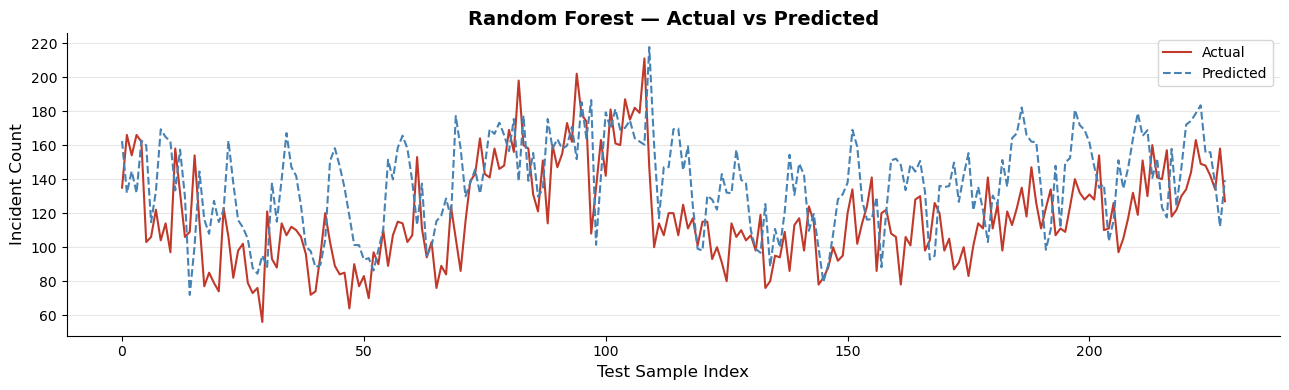

In [178]:
#  Evaluate best RF on hold-out test set 
rf_best    = rf_search.best_estimator_
pred_rf    = rf_best.predict(X_test)
rf_metrics = evaluate_model(y_test, pred_rf, 'Random Forest')
results_log.append(rf_metrics)

plot_actual_vs_predicted(y_test, pred_rf, 'Random Forest')
plt.tight_layout()
plt.show()

### Model 2 — XGBoost Regressor (with Hyperparameter Tuning)

In [179]:
# XGBoost hyperparameter search 
xgb_param_grid = {
    'n_estimators'  : [200, 400],
    'learning_rate' : [0.03, 0.05, 0.1],
    'max_depth'     : [3, 5, 7],
    'subsample'     : [0.8, 1.0],
}

xgb_base   = xgb.XGBRegressor(random_state=42, verbosity=0)
xgb_search = GridSearchCV(
    xgb_base, xgb_param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)

print(f'Best XGB params : {xgb_search.best_params_}')
print(f'Best CV RMSE    : {-xgb_search.best_score_:.2f}')

Best XGB params : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV RMSE    : 182.03



📊 XGBoost Performance
  RMSE : 36.73
  MAE  : 29.30
  R²   : -0.6687
  MAPE : 26.76%


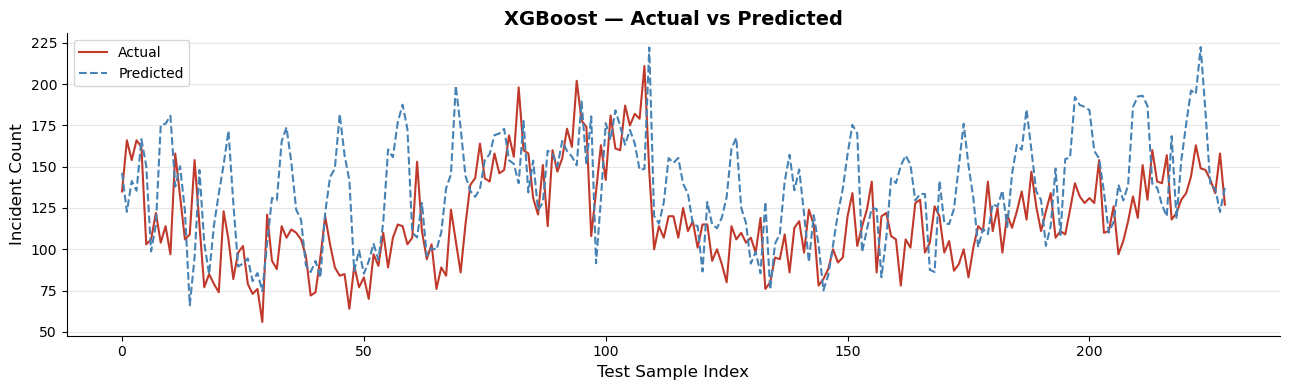

In [180]:
# Evaluate best XGB 
xgb_best    = xgb_search.best_estimator_
pred_xgb    = xgb_best.predict(X_test)
xgb_metrics = evaluate_model(y_test, pred_xgb, 'XGBoost')
results_log.append(xgb_metrics)

plot_actual_vs_predicted(y_test, pred_xgb, 'XGBoost')
plt.tight_layout()
plt.show()

### Model 3 — SARIMA (Univariate per Crime Type)

> SARIMA requires a proper `DatetimeIndex`. We demonstrate it on the most frequent crime type.

In [182]:
def run_sarima_for_type(monthly_df: pd.DataFrame, crime_type: str,
                        forecast_steps: int = 6) -> dict:
    """
    Fit a SARIMA(1,1,1)(1,1,1)[12] model for a single crime type.
    Returns a dict with the fitted model, in-sample RMSE, and forecasts.
    """
    #  Subset and build proper DatetimeIndex 
    subset = (
        monthly_df[monthly_df['TYPE'] == crime_type]
                  .sort_values(['year', 'month'])
                  .copy()
    )
    subset.index = pd.PeriodIndex(
        pd.to_datetime(subset[['year','month']].assign(day=1)), freq='M'
    )
    ts = subset['Incident_Counts']

    #  Stationarity check (ADF test) 
    adf_stat, adf_p, *_ = adfuller(ts.dropna())
    print(f'ADF p-value for "{crime_type}" : {adf_p:.4f} '
          + ('→ Stationary ✅' if adf_p < 0.05 else '→ Non-stationary, differencing needed'))

    #  Train/test split (last 12 months as test) 
    ts_train, ts_test = ts.iloc[:-12], ts.iloc[-12:]

    #  Fit SARIMA
    model   = sm.tsa.statespace.SARIMAX(ts_train, order=(1,1,1),
                                         seasonal_order=(1,1,1,12))
    results = model.fit(disp=False)

    #  In-sample test forecast 
    forecast_vals = results.forecast(steps=12)
    sarima_rmse   = np.sqrt(mean_squared_error(ts_test.values, forecast_vals.values))

    return {'model': results, 'ts_train': ts_train, 'ts_test': ts_test,
            'forecast': forecast_vals, 'rmse': sarima_rmse}


#  Run on top crime type 
top_crime   = type_counts.index[0]
sarima_out  = run_sarima_for_type(monthly_type, top_crime)

ADF p-value for "Theft from Vehicle" : 0.4321 → Non-stationary, differencing needed


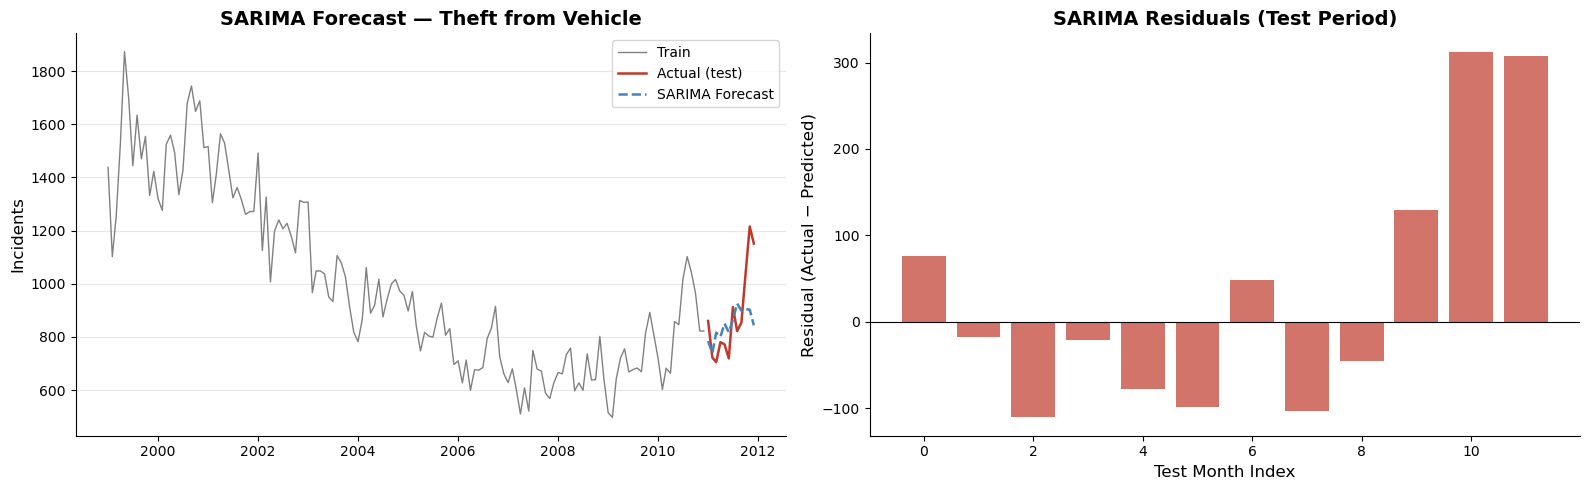


📊 SARIMA Performance
  RMSE : 146.82
  MAE  : 112.32
  R²   : 0.1859
  MAPE : 11.80%


In [183]:
#  Plot SARIMA forecast vs actual 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Time-series forecast plot
axes[0].plot(sarima_out['ts_train'].index.to_timestamp(),
             sarima_out['ts_train'].values,
             color='grey', label='Train', linewidth=1)
axes[0].plot(sarima_out['ts_test'].index.to_timestamp(),
             sarima_out['ts_test'].values,
             color=COLOR, label='Actual (test)', linewidth=1.8)
axes[0].plot(sarima_out['forecast'].index.to_timestamp(),
             sarima_out['forecast'].values,
             color='steelblue', linestyle='--', label='SARIMA Forecast', linewidth=1.8)
axes[0].set_title(f'SARIMA Forecast — {top_crime}', fontweight='bold')
axes[0].set_ylabel('Incidents')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Residual diagnostics
residuals = sarima_out['ts_test'].values - sarima_out['forecast'].values
axes[1].bar(range(len(residuals)), residuals, color=COLOR, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('SARIMA Residuals (Test Period)', fontweight='bold')
axes[1].set_xlabel('Test Month Index')
axes[1].set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.show()

sarima_metrics = evaluate_model(sarima_out['ts_test'].values,
                                sarima_out['forecast'].values, 'SARIMA')
results_log.append(sarima_metrics)


## Model Comparison & Feature Importance

In [184]:
#  Comparison table 
comparison_df = pd.DataFrame(results_log).set_index('Model')
comparison_df = comparison_df.round(3)
print('\n🏆 Model Comparison Summary:')
print(comparison_df.to_string())


🏆 Model Comparison Summary:
                  RMSE      MAE     R2    MAPE
Model                                         
Random Forest   34.126   28.404 -0.441  26.340
XGBoost         36.728   29.300 -0.669  26.765
SARIMA         146.817  112.317  0.186  11.798


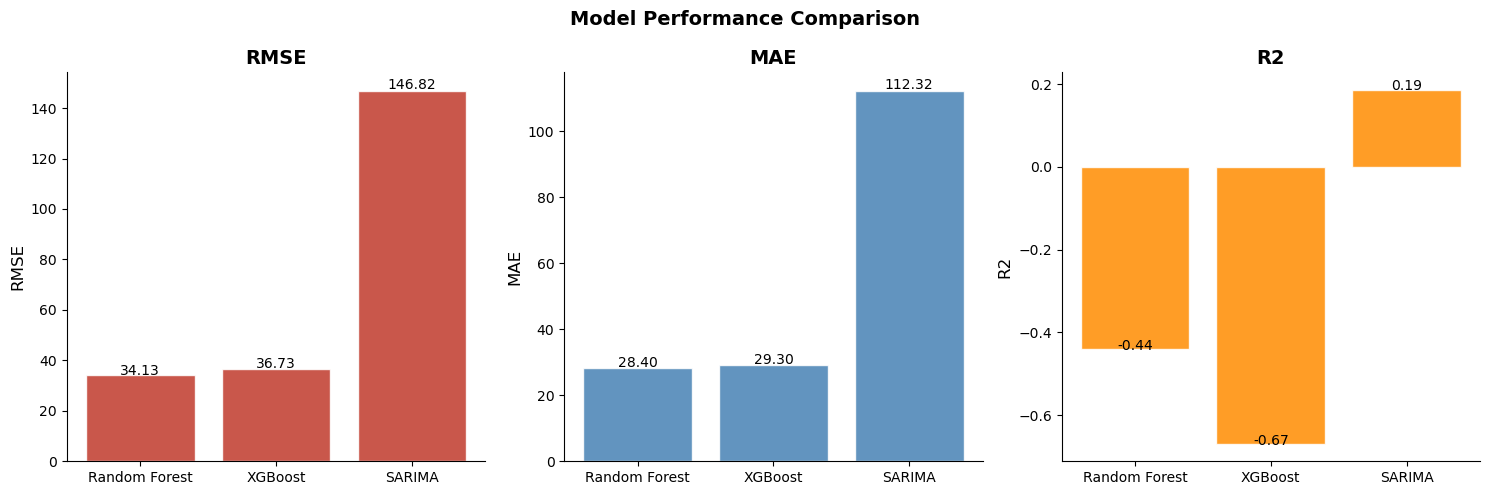

In [185]:
#  Visual comparison 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_to_plot = ['RMSE', 'MAE', 'R2']
colors = ['#c0392b', 'steelblue', 'darkorange']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    vals = comparison_df[metric]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * bar.get_height(),
                f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

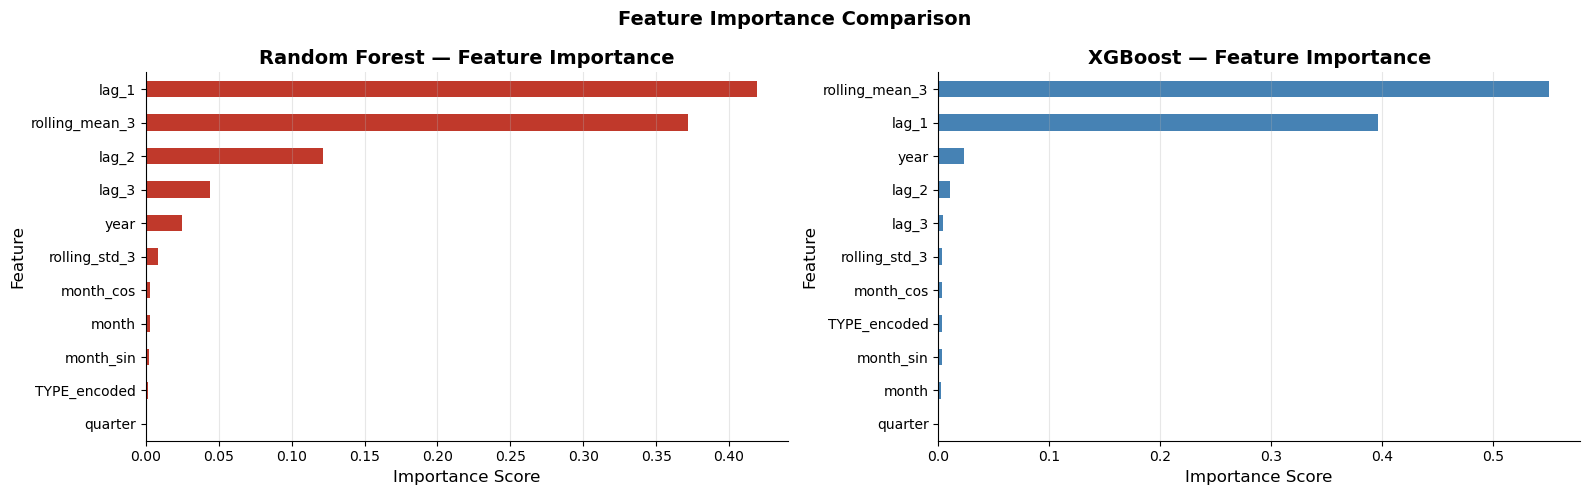


💡 Interpretation:
  RF top feature  : lag_1
  XGB top feature : rolling_mean_3


In [186]:
# Feature Importance (with proper feature names) 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model, name in [(axes[0], rf_best, 'Random Forest'),
                         (axes[1], xgb_best, 'XGBoost')]:
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    importances.sort_values().plot(kind='barh', ax=ax,
                                   color=COLOR if name=='Random Forest' else 'steelblue')
    ax.set_title(f'{name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Interpretation:')
top_rf_feat  = pd.Series(rf_best.feature_importances_, index=FEATURE_COLS).idxmax()
top_xgb_feat = pd.Series(xgb_best.feature_importances_, index=FEATURE_COLS).idxmax()
print(f'  RF top feature  : {top_rf_feat}')
print(f'  XGB top feature : {top_xgb_feat}')

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [153]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [154]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [155]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [156]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [157]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [158]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [159]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***